# Feature Engineering for Traffic Demand Modeling and Signal Timing Optimization

This notebook builds optimization-oriented features from the hourly traffic demand dataset rather than forecasting lags and rolling-window predictors.


## 1) Imports


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from sklearn.neighbors import BallTree

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


## 2) Load the Main Hourly Optimization Dataset

### Load Hourly Traffic Dataset

This notebook depends on the hourly traffic demand dataset produced upstream in `notebooks/00_raw_preprocessing.ipynb`. The guard below makes that dependency explicit so the feature engineering stage is reproducible and fails with a clear message if the preprocessing notebook has not been run.


In [2]:
upstream_hourly_path = Path("data/processed/traffic_signal_hourly_dataset_2015_2019.csv")

if not upstream_hourly_path.exists():
    raise FileNotFoundError(
        "Missing upstream dataset: data/processed/traffic_signal_hourly_dataset_2015_2019.csv. "
        "Run notebooks/00_raw_preprocessing.ipynb first to create the hourly traffic dataset "
        "before running notebooks/04_feature_engineering.ipynb."
    )

candidate_paths = [
    upstream_hourly_path,
    Path("/mnt/data/traffic_signal_hourly_dataset_2015_2019.csv"),
]

loaded_path = None
df_raw = None
for path in candidate_paths:
    if path.exists():
        df_raw = pd.read_csv(path)
        loaded_path = str(path)
        break

if df_raw is None:
    raise FileNotFoundError(
        "No hourly optimization input file found. Expected one of: "
        f"{[str(p) for p in candidate_paths]}"
    )

print(f"Loaded file: {loaded_path}")
print(f"df_raw.shape: {df_raw.shape}")
print("df_raw.columns:")
print(df_raw.columns.tolist())
display(df_raw.head(5))


Loaded file: data/processed/traffic_signal_hourly_dataset_2015_2019.csv
df_raw.shape: (138672, 21)
df_raw.columns:
['location_id', 'hour', 'hourly_volume', 'location_name', 'centreline_id', 'direction', 'date', 'hour_of_day', 'year', 'month', 'day_of_week', 'is_weekend', 'daily_total_volume', 'peak_hour_volume', 'peak_ratio', 'peak_hour_concentration', 'observed_hour_count', 'hourly_share_of_daily_volume', 'is_peak_hour', 'estimated_arrival_rate_vph', 'estimated_arrival_rate_vpm']


,location_id,hour,hourly_volume,location_name,centreline_id,direction,date,hour_of_day,year,month,day_of_week,is_weekend,daily_total_volume,peak_hour_volume,peak_ratio,peak_hour_concentration,observed_hour_count,hourly_share_of_daily_volume,is_peak_hour,estimated_arrival_rate_vph,estimated_arrival_rate_vpm
0,10010625_WB,2015-05-14 00:00:00,286,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,0,2015,5,3,0,17031,1809,0.106218,2.549234,24,0.016793,0,286,4.766667
1,10010625_WB,2015-05-14 01:00:00,198,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,1,2015,5,3,0,17031,1809,0.106218,2.549234,24,0.011626,0,198,3.300000
2,10010625_WB,2015-05-14 02:00:00,134,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2,2015,5,3,0,17031,1809,0.106218,2.549234,24,0.007868,0,134,2.233333
3,10010625_WB,2015-05-14 03:00:00,118,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,3,2015,5,3,0,17031,1809,0.106218,2.549234,24,0.006929,0,118,1.966667
4,10010625_WB,2015-05-14 04:00:00,131,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,4,2015,5,3,0,17031,1809,0.106218,2.549234,24,0.007692,0,131,2.183333


## 3) Standardize the Main Optimization Dataset

This step keeps the existing hour-level feature engineering pipeline intact and ensures the canonical traffic dataset is ready before spatial enrichment is added.


In [3]:
if df_raw is None:
    raise RuntimeError("Input dataset is not loaded. Run the load-data cell first.")

df = df_raw.copy()
df["hour"] = pd.to_datetime(df["hour"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.floor("D")

required_cols = [
    "location_id",
    "date",
    "hour",
    "hour_of_day",
    "hourly_volume",
    "daily_total_volume",
    "peak_hour_volume",
    "peak_ratio",
]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

if "direction" not in df.columns:
    df["direction"] = df["location_id"].astype(str).str.split("_").str[-1]

df = df.dropna(subset=["date", "hour", "hourly_volume", "daily_total_volume"]).copy()
df = df.sort_values(["location_id", "hour"]).reset_index(drop=True)

print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique locations: {df['location_id'].nunique():,}")


Date range: 2015-03-31 to 2019-11-05
Unique locations: 914


## Mapping Traffic Count Locations to Signalized Intersections

Traffic count stations and signalized intersections come from different City of Toronto datasets and do not share a common identifier. Because there is no direct join key between the traffic-count records and the signal inventory, the notebook uses geographic nearest-neighbor matching to map each traffic count location to the nearest signalized intersection.

Conceptually, the mapping workflow is:
1. extract unique traffic locations from the traffic dataset
2. load signalized intersection coordinates from the signal dataset
3. use haversine distance with a spatial tree (`BallTree`)
4. identify the nearest signal for each traffic location
5. attach signal metadata and distance back to the hourly traffic dataset


### Load Signal Dataset

The mapping step uses CSV files only. It reads the Toronto traffic signal inventory from `data/raw/signals/traffic_signals.csv` and uses the raw 2015-2019 traffic dataset, with a processed fallback only if coordinate fields are unavailable.


In [4]:
traffic_reference_candidates = [
    Path("data/raw/traffic/svc_raw_data_volume_2015_2019.csv"),
    Path("data/processed/modeling_dataset_2015_2019.csv"),
]
signal_path = Path("data/raw/signals/traffic_signals.csv")

traffic_reference_path = next((path for path in traffic_reference_candidates if path.exists()), None)
if traffic_reference_path is None:
    raise FileNotFoundError(
        "No traffic reference file found for coordinate mapping. "
        f"Checked: {[str(path) for path in traffic_reference_candidates]}"
    )

if not signal_path.exists():
    raise FileNotFoundError(f"Missing signal dataset: {signal_path}")

traffic_ref = pd.read_csv(traffic_reference_path)
signal_df = pd.read_csv(signal_path)

print(f"Traffic reference file: {traffic_reference_path}")
print(f"Signal file: {signal_path}")
print("\nTraffic reference columns:")
print(traffic_ref.columns.tolist())
print("\nSignal columns:")
print(signal_df.columns.tolist())


Traffic reference file: data/raw/traffic/svc_raw_data_volume_2015_2019.csv
Signal file: data/raw/signals/traffic_signals.csv

Traffic reference columns:
['id', 'count_id', 'location_name', 'longitude', 'latitude', 'centreline_id', 'time_start', 'time_end', 'direction', 'volume_15min']

Signal columns:
['_id', 'PX', 'MAIN_STREET', 'MIDBLOCK_ROUTE', 'SIDE1_STREET', 'SIDE2_STREET', 'PRIVATE_ACCESS', 'ADDITIONAL_INFO', 'ACTIVATIONDATE', 'SIGNALSYSTEM', 'NON_SYSTEM', 'CONTROL_MODE', 'PEDWALKSPEED', 'APS_OPERATION', 'NUMBEROFAPPROACHES', 'OBJECTID', 'GEO_ID', 'NODE_ID', 'AUDIBLEPEDSIGNAL', 'TRANSIT_PREEMPT', 'FIRE_PREEMPT', 'RAIL_PREEMPT', 'MI_PRINX', 'BICYCLE_SIGNAL', 'UPS', 'LED_BLANKOUT_SIGN', 'LPI_NORTH_IMPLEMENTATION_DATE', 'LPI_SOUTH_IMPLEMENTATION_DATE', 'LPI_EAST_IMPLEMENTATION_DATE', 'LPI_WEST_IMPLEMENTATION_DATE', 'LPI_COMMENT', 'geometry']


### Extract Unique Traffic Locations

The Toronto SVC traffic dataset uses stable `latitude` and `longitude` fields for traffic count station coordinates. This notebook therefore uses explicit coordinate column names rather than dynamic schema matching.


In [5]:
traffic_lat_col = "latitude"
traffic_lon_col = "longitude"
traffic_reference_used = str(traffic_reference_path)

if traffic_lat_col not in traffic_ref.columns or traffic_lon_col not in traffic_ref.columns:
    fallback_path = Path("data/processed/modeling_dataset_2015_2019.csv")
    if traffic_reference_path != fallback_path and fallback_path.exists():
        traffic_ref = pd.read_csv(fallback_path)
        traffic_reference_path = fallback_path
        traffic_reference_used = str(traffic_reference_path)

    if traffic_lat_col not in traffic_ref.columns or traffic_lon_col not in traffic_ref.columns:
        raise ValueError(
            "Expected coordinate columns 'latitude' and 'longitude' were not found in the traffic dataset."
        )

print(f"Traffic coordinate columns: lat={traffic_lat_col}, lon={traffic_lon_col}")

traffic_ref[traffic_lat_col] = pd.to_numeric(traffic_ref[traffic_lat_col], errors="coerce")
traffic_ref[traffic_lon_col] = pd.to_numeric(traffic_ref[traffic_lon_col], errors="coerce")

if "location_id" not in traffic_ref.columns:
    if "centreline_id" in traffic_ref.columns:
        centreline_source = pd.to_numeric(traffic_ref["centreline_id"], errors="coerce").astype("Int64")
        base_loc = centreline_source.astype(str)
        missing_base = centreline_source.isna()
        name_source = traffic_ref["location_name"].astype(str).str.strip() if "location_name" in traffic_ref.columns else pd.Series("UNKNOWN", index=traffic_ref.index)
        base_loc = base_loc.mask(missing_base, name_source)
    else:
        base_loc = traffic_ref["location_name"].astype(str).str.strip()

    direction_source = traffic_ref["direction"].astype(str).str.strip().replace({"": "UNK"}) if "direction" in traffic_ref.columns else pd.Series("UNK", index=traffic_ref.index)
    traffic_ref["location_id"] = base_loc + "_" + direction_source

traffic_location_cols = [
    col for col in ["location_id", "location_name", "centreline_id", "direction"]
    if col in traffic_ref.columns
]
traffic_locations = (
    traffic_ref[traffic_location_cols + [traffic_lat_col, traffic_lon_col]]
    .dropna(subset=[traffic_lat_col, traffic_lon_col])
    .drop_duplicates(subset=["location_id"])
    .rename(
        columns={
            traffic_lat_col: "traffic_latitude",
            traffic_lon_col: "traffic_longitude",
        }
    )
    .reset_index(drop=True)
)

print(f"Traffic coordinate source used: {traffic_reference_used}")
print(f"Unique traffic locations with coordinates: {len(traffic_locations):,}")
display(traffic_locations.head())


Traffic coordinate columns: lat=latitude, lon=longitude


Traffic coordinate source used: data/raw/traffic/svc_raw_data_volume_2015_2019.csv
Unique traffic locations with coordinates: 914


,location_id,location_name,centreline_id,direction,traffic_latitude,traffic_longitude
0,907211_WB,Finch Ave W: West Humber Trl - Finch E / Hwy 4...,907211,WB,43.734332,-79.626335
1,30139432_EB,Dundas St W: Spadina Ave - Willison Pl,30139432,EB,43.652810,-79.398585
2,14020151_WB,Dundas St W: Lane E of Spadina and S of Dundas...,14020151,WB,43.653000,-79.397730
3,7762832_EB,Dundas St W: Yonge St - Bay St,7762832,EB,43.656025,-79.382350
4,20230566_SB,Dundas St W: Bloor St W - Summerland Ter,20230566,SB,43.642912,-79.532592


### Compute Nearest Signal Using BallTree

The signal CSV stores coordinates inside a geometry field. Those coordinates are extracted and matched to traffic locations with `BallTree` using haversine distance, which is appropriate for latitude and longitude on the earth's surface.


In [6]:
def parse_signal_geometry(value):
    if pd.isna(value):
        return np.nan, np.nan
    try:
        geometry = json.loads(value)
        coordinates = geometry.get("coordinates", [])
        if coordinates and isinstance(coordinates[0], list) and len(coordinates[0]) >= 2:
            longitude, latitude = coordinates[0][0], coordinates[0][1]
            return latitude, longitude
    except Exception:
        return np.nan, np.nan
    return np.nan, np.nan


signal_coords = signal_df["geometry"].apply(parse_signal_geometry)
signal_df[["signal_latitude", "signal_longitude"]] = pd.DataFrame(signal_coords.tolist(), index=signal_df.index)

signal_id_col = next((col for col in ["GEO_ID", "NODE_ID", "OBJECTID", "_id"] if col in signal_df.columns), None)
if signal_id_col is None:
    raise ValueError("Unable to detect a stable signal identifier column.")

signal_name_parts = []
for col in ["MAIN_STREET", "SIDE1_STREET", "SIDE2_STREET", "MIDBLOCK_ROUTE"]:
    if col in signal_df.columns:
        signal_name_parts.append(signal_df[col].fillna("").astype(str).str.strip())

if signal_name_parts:
    signal_name_df = pd.concat(signal_name_parts, axis=1)
    signal_df["signal_name"] = signal_name_df.apply(
        lambda row: " / ".join([value for value in row if value and value.lower() != "nan"]),
        axis=1,
    )
    signal_df["signal_name"] = signal_df["signal_name"].replace("", np.nan).fillna(signal_df[signal_id_col].astype(str))
else:
    signal_df["signal_name"] = signal_df[signal_id_col].astype(str)

signal_locations = (
    signal_df[
        [
            signal_id_col,
            "signal_name",
            "signal_latitude",
            "signal_longitude",
        ]
    ]
    .dropna(subset=["signal_latitude", "signal_longitude"])
    .drop_duplicates(subset=[signal_id_col])
    .rename(columns={signal_id_col: "nearest_signal_id"})
    .reset_index(drop=True)
)

EARTH_RADIUS_M = 6_371_000
traffic_coords = traffic_locations[["traffic_latitude", "traffic_longitude"]].to_numpy(dtype=float)
signal_coords = signal_locations[["signal_latitude", "signal_longitude"]].to_numpy(dtype=float)
traffic_coords_rad = np.radians(traffic_coords)
signal_coords_rad = np.radians(signal_coords)

tree = BallTree(signal_coords_rad, metric="haversine")
distances_rad, indices = tree.query(traffic_coords_rad, k=1)

MAX_SIGNAL_MATCH_DISTANCE_M = 150

traffic_signal_map = traffic_locations.copy()
traffic_signal_map["nearest_signal_id"] = signal_locations.iloc[indices.flatten()]["nearest_signal_id"].values
traffic_signal_map["nearest_signal_name"] = signal_locations.iloc[indices.flatten()]["signal_name"].values
traffic_signal_map["nearest_signal_latitude"] = signal_locations.iloc[indices.flatten()]["signal_latitude"].values
traffic_signal_map["nearest_signal_longitude"] = signal_locations.iloc[indices.flatten()]["signal_longitude"].values
traffic_signal_map["distance_to_signal_m"] = distances_rad.flatten() * EARTH_RADIUS_M
traffic_signal_map["is_signalized_match"] = (
    traffic_signal_map["distance_to_signal_m"] <= MAX_SIGNAL_MATCH_DISTANCE_M
)

traffic_signal_map.loc[
    ~traffic_signal_map["is_signalized_match"],
    [
        "nearest_signal_id",
        "nearest_signal_name",
        "nearest_signal_latitude",
        "nearest_signal_longitude",
    ],
] = pd.NA

valid_matches = int(traffic_signal_map["is_signalized_match"].sum())
total_locations = len(traffic_signal_map)

print(f"Signal records with usable coordinates: {len(signal_locations):,}")
print(f"Valid signal matches within {MAX_SIGNAL_MATCH_DISTANCE_M}m: {valid_matches}/{total_locations}")
display(traffic_signal_map.head())


Signal records with usable coordinates: 2,416
Valid signal matches within 150m: 699/914


,location_id,location_name,centreline_id,direction,traffic_latitude,traffic_longitude,nearest_signal_id,nearest_signal_name,nearest_signal_latitude,nearest_signal_longitude,distance_to_signal_m,is_signalized_match
0,907211_WB,Finch Ave W: West Humber Trl - Finch E / Hwy 4...,907211,WB,43.734332,-79.626335,NaN,NaN,NaN,NaN,684.098952,False
1,30139432_EB,Dundas St W: Spadina Ave - Willison Pl,30139432,EB,43.652810,-79.398585,14020151.0,SPADINA AVE / DUNDAS ST W,43.652944,-79.398049,45.624515,True
2,14020151_WB,Dundas St W: Lane E of Spadina and S of Dundas...,14020151,WB,43.653000,-79.397730,14020151.0,SPADINA AVE / DUNDAS ST W,43.652944,-79.398049,26.409418,True
3,7762832_EB,Dundas St W: Yonge St - Bay St,7762832,EB,43.656025,-79.382350,10906585.0,DUNDAS ST W / BAY ST,43.655715,-79.383766,119.017282,True
4,20230566_SB,Dundas St W: Bloor St W - Summerland Ter,20230566,SB,43.642912,-79.532592,20230566.0,BLOOR ST W / DUNDAS ST W / DUNBLOOR RD,43.642641,-79.532365,35.187623,True


### Geographic Distance Calculation

The nearest traffic signal is identified using a `BallTree` spatial index with the haversine metric. Since latitude and longitude represent positions on the Earth's surface, the haversine formula is used to compute great-circle distances. The resulting distances are converted from radians to meters using the Earth's radius.


### Signal Matching Distance Threshold

To avoid incorrectly assigning traffic count locations to distant signalized intersections, a maximum nearest-signal distance threshold of 150 meters is applied after spatial matching. If the nearest signal is farther than this threshold, the traffic location is not considered a valid signalized intersection match.


### Merge Signal Mapping Back Into Dataset

The nearest-signal mapping table is merged back into the full hourly optimization dataset so every traffic record inherits the nearest signal identifier, signal metadata, match distance, and threshold-based validity flag.

### Validate Mapping Results

After merging, the notebook reports the number of unique traffic locations, the number of signal records, the number of mapped records, and basic distance diagnostics to verify that the spatial join behaved as expected.


In [7]:
df = df.merge(
    traffic_signal_map[
        [
            "location_id",
            "traffic_latitude",
            "traffic_longitude",
            "nearest_signal_id",
            "nearest_signal_name",
            "nearest_signal_latitude",
            "nearest_signal_longitude",
            "distance_to_signal_m",
            "is_signalized_match",
        ]
    ],
    on="location_id",
    how="left",
)

mapped_record_count = int(df["nearest_signal_id"].notna().sum())
distance_stats = df["distance_to_signal_m"].agg(["min", "mean", "max"])

print(f"Number of unique traffic locations: {traffic_locations['location_id'].nunique():,}")
print(f"Number of signals: {len(signal_locations):,}")
print(f"Number of mapped records: {mapped_record_count:,}")
print(
    "Distance statistics (meters): "
    f"min={distance_stats['min']:.2f}, "
    f"mean={distance_stats['mean']:.2f}, "
    f"max={distance_stats['max']:.2f}"
)
print("\nFull distance summary:")
display(df["distance_to_signal_m"].describe().to_frame("distance_to_signal_m"))

sample_cols = [
    "location_id",
    "location_name",
    "traffic_latitude",
    "traffic_longitude",
    "nearest_signal_id",
    "nearest_signal_name",
    "nearest_signal_latitude",
    "nearest_signal_longitude",
    "distance_to_signal_m",
    "is_signalized_match",
]
display(
    df[sample_cols]
    .drop_duplicates(subset=["location_id"])
    .sort_values("distance_to_signal_m")
    .head(10)
)


Number of unique traffic locations: 914
Number of signals: 2,416
Number of mapped records: 108,696
Distance statistics (meters): min=0.03, mean=137.89, max=2133.87

Full distance summary:


,distance_to_signal_m
count,138672.000000
mean,137.892459
std,225.600389
min,0.028307
25%,46.868757
50%,73.440047
75%,139.395735
max,2133.871010


,location_id,location_name,traffic_latitude,traffic_longitude,nearest_signal_id,nearest_signal_name,nearest_signal_latitude,nearest_signal_longitude,distance_to_signal_m,is_signalized_match
83928,437149_WB,Willowdale Ave: Cummer Ave - Wedgewood Dr,43.788663,-79.409917,437149.0,CUMMER AVE / WILLOWDALE AVE,43.788663,-79.409917,0.028307,True
15192,107240_EB,Hwy 401 Collectors E / Progress Av Ramp,43.778444,-79.259173,107543.0,PROGRESS AVE / 401 C E PROGRESS AV RAMP / PRIV...,43.778444,-79.259173,0.030446,True
15264,107240_WB,Hwy 401 Collectors E / Progress Av Ramp,43.778444,-79.259173,107543.0,PROGRESS AVE / 401 C E PROGRESS AV RAMP / PRIV...,43.778444,-79.259173,0.030446,True
92064,446207_NB,Keele St: Lawrence Ave W - Wyndale Dr,43.708659,-79.478062,446206.0,KEELE ST / LAWRENCE AVE W,43.708659,-79.478062,0.038092,True
72840,30075982_SB,Morningside Ave: Ellesmere Rd - Military Trl,43.785344,-79.193342,106555.0,ELLESMERE RD / MORNINGSIDE AVE,43.785344,-79.193342,0.044645,True
66792,30015011_SB,Birchmount Rd: Ashtonbee Rd - Bertrand Ave,43.732862,-79.278903,111234.0,BIRCHMOUNT RD / ASHTONBEE RD,43.732862,-79.278902,0.065406,True
93264,4840733_WB,Corporate Dr: Toyota Pl - Progress Ave,43.780154,-79.243843,9345078.0,PROGRESS AVE / BELLAMY RD N / CORPORATE DR,43.780154,-79.243842,0.074582,True
122520,907129_EB,Thistle Down Blvd: Riverdale Dr - Thistle Down...,43.735356,-79.561391,10985942.0,ALBION RD / THISTLE DOWN BLVD / RIVERDALE DR,43.735356,-79.561390,0.081150,True
47328,14037691_WB,University Ave: Lane S of Wellington and W of ...,43.646384,-79.384100,3065748.0,UNIVERSITY AVE / WELLINGTON ST W,43.646383,-79.384099,0.108166,True
110112,820_NB,Millwood Rd: Laird Dr - Redway Rd,43.703142,-79.360559,3244804.0,LAIRD DR / MILLWOOD RD,43.703141,-79.360558,0.122035,True


Smaller nearest-signal distances indicate stronger spatial confidence that a traffic count location is associated with a nearby controlled intersection. Distances beyond the 150 meter threshold are retained for auditability, but those locations are not treated as valid signalized matches because the nearest intersection is too far away for a strong operational association.


## 5) Define Feature Groups

The engineered features are organized into two project-relevant groups:
- **Descriptive demand features:** summarize when and where traffic demand is strongest.
- **Optimization input features:** translate those patterns into interpretable proxies for green splits, critical flow, and phase pressure.


In [8]:
FEATURES_TEMPORAL = [
    "year",
    "month",
    "quarter",
    "day_of_week",
    "is_weekend",
    "hour_of_day",
    "AM_peak_flag",
    "PM_peak_flag",
]

FEATURES_DEMAND = [
    "daily_total_volume",
    "hourly_volume",
    "peak_hour_volume",
    "peak_ratio",
    "hourly_share_of_daily_volume",
    "normalized_demand_intensity",
]

FEATURES_OPTIMIZATION = [
    "estimated_arrival_rate_vph",
    "approach_demand_proxy",
    "directional_imbalance",
    "green_split_weight_proxy",
    "critical_flow_proxy",
    "saturation_proxy",
]

FEATURES_ALL = FEATURES_TEMPORAL + FEATURES_DEMAND + FEATURES_OPTIMIZATION

print("FEATURES_TEMPORAL =", FEATURES_TEMPORAL)
print("FEATURES_DEMAND =", FEATURES_DEMAND)
print("FEATURES_OPTIMIZATION =", FEATURES_OPTIMIZATION)


FEATURES_TEMPORAL = ['year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'hour_of_day', 'AM_peak_flag', 'PM_peak_flag']
FEATURES_DEMAND = ['daily_total_volume', 'hourly_volume', 'peak_hour_volume', 'peak_ratio', 'hourly_share_of_daily_volume', 'normalized_demand_intensity']
FEATURES_OPTIMIZATION = ['estimated_arrival_rate_vph', 'approach_demand_proxy', 'directional_imbalance', 'green_split_weight_proxy', 'critical_flow_proxy', 'saturation_proxy']


## 6) Create Temporal Demand Features


In [9]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["AM_peak_flag"] = df["hour_of_day"].between(7, 9).astype(int)
df["PM_peak_flag"] = df["hour_of_day"].between(15, 18).astype(int)

display(df[["date", "hour", *FEATURES_TEMPORAL]].head())


,date,hour,year,month,quarter,day_of_week,is_weekend,hour_of_day,AM_peak_flag,PM_peak_flag
0,2015-05-14,2015-05-14 00:00:00,2015,5,2,3,0,0,0,0
1,2015-05-14,2015-05-14 01:00:00,2015,5,2,3,0,1,0,0
2,2015-05-14,2015-05-14 02:00:00,2015,5,2,3,0,2,0,0
3,2015-05-14,2015-05-14 03:00:00,2015,5,2,3,0,3,0,0
4,2015-05-14,2015-05-14 04:00:00,2015,5,2,3,0,4,0,0


## 7) Create Demand Intensity Features


In [10]:
if "hourly_share_of_daily_volume" not in df.columns:
    df["hourly_share_of_daily_volume"] = np.where(
        df["daily_total_volume"] > 0,
        df["hourly_volume"] / df["daily_total_volume"],
        np.nan,
    )

location_median = df.groupby("location_id")["hourly_volume"].transform("median")
df["normalized_demand_intensity"] = np.where(
    location_median > 0,
    df["hourly_volume"] / location_median,
    np.nan,
)

display(
    df[
        [
            "location_id",
            "hour",
            "hourly_volume",
            "daily_total_volume",
            "peak_hour_volume",
            "peak_ratio",
            "hourly_share_of_daily_volume",
            "normalized_demand_intensity",
        ]
    ].head()
)


,location_id,hour,hourly_volume,daily_total_volume,peak_hour_volume,peak_ratio,hourly_share_of_daily_volume,normalized_demand_intensity
0,10010625_WB,2015-05-14 00:00:00,286,17031,1809,0.106218,0.016793,0.512545
1,10010625_WB,2015-05-14 01:00:00,198,17031,1809,0.106218,0.011626,0.354839
2,10010625_WB,2015-05-14 02:00:00,134,17031,1809,0.106218,0.007868,0.240143
3,10010625_WB,2015-05-14 03:00:00,118,17031,1809,0.106218,0.006929,0.211470
4,10010625_WB,2015-05-14 04:00:00,131,17031,1809,0.106218,0.007692,0.234767


These features describe traffic demand directly. They are more appropriate than forecasting lags because the capstone now needs interpretable operational inputs for signal timing rather than one-step-ahead prediction features.


## 8) Create Optimization Input Features


In [11]:
df["estimated_arrival_rate_vph"] = df["hourly_volume"]
df["approach_demand_proxy"] = df["hourly_volume"]

centreline_hour_total = df.groupby(["centreline_id", "date", "hour"])["hourly_volume"].transform("sum")
df["directional_imbalance"] = np.where(
    centreline_hour_total > 0,
    df["hourly_volume"] / centreline_hour_total,
    np.nan,
)

centreline_daily_total = df.groupby(["centreline_id", "date"])["hourly_volume"].transform("sum")
df["green_split_weight_proxy"] = np.where(
    centreline_daily_total > 0,
    df["hourly_volume"] / centreline_daily_total,
    np.nan,
)

location_peak = df.groupby(["location_id", "date"])["hourly_volume"].transform("max")
df["critical_flow_proxy"] = np.where(
    location_peak > 0,
    df["hourly_volume"] / location_peak,
    np.nan,
)
df["saturation_proxy"] = df["critical_flow_proxy"]

display(
    df[
        [
            "location_id",
            "direction",
            "hour",
            "estimated_arrival_rate_vph",
            "approach_demand_proxy",
            "directional_imbalance",
            "green_split_weight_proxy",
            "critical_flow_proxy",
            "saturation_proxy",
        ]
    ].head()
)


,location_id,direction,hour,estimated_arrival_rate_vph,approach_demand_proxy,directional_imbalance,green_split_weight_proxy,critical_flow_proxy,saturation_proxy
0,10010625_WB,WB,2015-05-14 00:00:00,286,286,1.0,0.016793,0.158098,0.158098
1,10010625_WB,WB,2015-05-14 01:00:00,198,198,1.0,0.011626,0.109453,0.109453
2,10010625_WB,WB,2015-05-14 02:00:00,134,134,1.0,0.007868,0.074074,0.074074
3,10010625_WB,WB,2015-05-14 03:00:00,118,118,1.0,0.006929,0.065229,0.065229
4,10010625_WB,WB,2015-05-14 04:00:00,131,131,1.0,0.007692,0.072416,0.072416


These optimization-oriented features remain proxies rather than measured control variables. They are intentionally simple and defensible given the available Toronto count data, while still giving later notebooks practical inputs for scenario design and signal split weighting.


## 9) Quality Checks


,missing_pct
directional_imbalance,0.0044
normalized_demand_intensity,0.0010
saturation_proxy,0.0002
critical_flow_proxy,0.0002
hourly_share_of_daily_volume,0.0002
peak_ratio,0.0002
month,0.0000
green_split_weight_proxy,0.0000
approach_demand_proxy,0.0000
estimated_arrival_rate_vph,0.0000


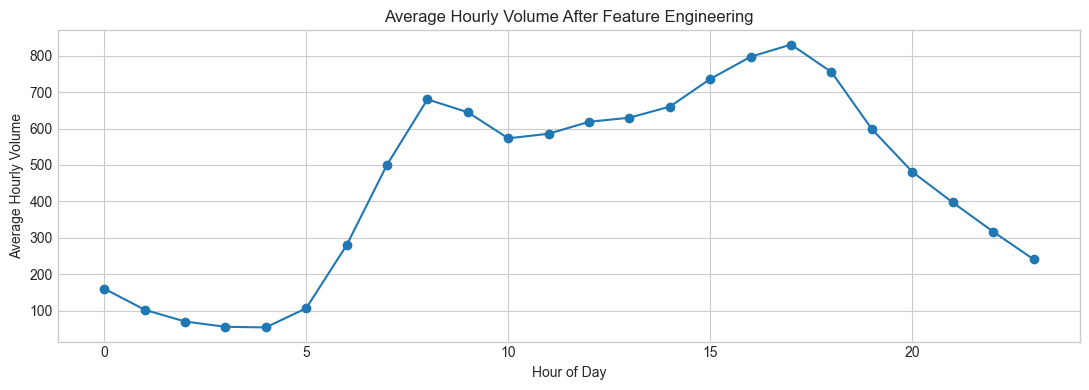

In [12]:
feature_check = df[FEATURES_ALL].isna().mean().sort_values(ascending=False).to_frame("missing_pct")
display(feature_check.round(4))

hourly_profile = (
    df.groupby("hour_of_day")
    .agg(hourly_volume_mean=("hourly_volume", "mean"))
    .reset_index()
    .sort_values(by="hour_of_day")
)
hourly_profile_x = hourly_profile["hour_of_day"].to_numpy(dtype=float)
hourly_profile_y = hourly_profile["hourly_volume_mean"].to_numpy(dtype=float)

plt.figure(figsize=(11, 4))
plt.plot(
    hourly_profile_x,
    hourly_profile_y,
    marker="o",
)
plt.title("Average Hourly Volume After Feature Engineering")
plt.xlabel("Hour of Day")
plt.ylabel("Average Hourly Volume")
plt.tight_layout()
plt.show()


## 10) Deterministic Output Schema


In [13]:
ordered_cols = [
    "location_id",
    "location_name",
    "centreline_id",
    "direction",
    "date",
    "hour",
    "traffic_latitude",
    "traffic_longitude",
    "nearest_signal_id",
    "nearest_signal_name",
    "nearest_signal_latitude",
    "nearest_signal_longitude",
    "distance_to_signal_m",
    "is_signalized_match",
    *FEATURES_TEMPORAL,
    *FEATURES_DEMAND,
    *FEATURES_OPTIMIZATION,
    "is_peak_hour",
    "observed_hour_count",
]

final_cols = []
seen = set()
for col in ordered_cols:
    if col in df.columns and col not in seen:
        final_cols.append(col)
        seen.add(col)

df_fe = df.loc[:, final_cols].copy()

print("Final column order:")
print(final_cols)
print(f"df_fe.shape: {df_fe.shape}")


Final column order:
['location_id', 'location_name', 'centreline_id', 'direction', 'date', 'hour', 'traffic_latitude', 'traffic_longitude', 'nearest_signal_id', 'nearest_signal_name', 'nearest_signal_latitude', 'nearest_signal_longitude', 'distance_to_signal_m', 'is_signalized_match', 'year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'hour_of_day', 'AM_peak_flag', 'PM_peak_flag', 'daily_total_volume', 'hourly_volume', 'peak_hour_volume', 'peak_ratio', 'hourly_share_of_daily_volume', 'normalized_demand_intensity', 'estimated_arrival_rate_vph', 'approach_demand_proxy', 'directional_imbalance', 'green_split_weight_proxy', 'critical_flow_proxy', 'saturation_proxy', 'is_peak_hour', 'observed_hour_count']
df_fe.shape: (138672, 36)


### Save Final Feature Dataset


In [14]:
output_path = Path("data/processed/signal_optimization_features_2015_2019.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
df_fe.to_csv(output_path, index=False)

print(f"Saved file: {output_path}")
print(f"File exists: {output_path.exists()}")


Saved file: data/processed/signal_optimization_features_2015_2019.csv
File exists: True


## 12) Feature Engineering Summary

- **Input file used:** the hourly traffic signal dataset created in `00_raw_preprocessing.ipynb`
- **Signal mapping inputs:** `data/raw/traffic/svc_raw_data_volume_2015_2019.csv` and `data/raw/signals/traffic_signals.csv`
- **Primary focus:** descriptive demand features, optimization input proxies, and nearest-signal enrichment
- **Forecasting lag features:** intentionally removed as the main design pattern
- **Output:** a clean hourly feature table for downstream candidate selection, baseline timing, optimization, simulation, and later map-based visualization


In [15]:
print(f"Input file used: {loaded_path}")
print(f"Traffic coordinate reference used: {traffic_reference_used}")
print("Signal reference used: data/raw/signals/traffic_signals.csv")
print(f"Final rows/cols: {df_fe.shape[0]} rows, {df_fe.shape[1]} cols")
print(f"Final date range: {df_fe['date'].min().date()} to {df_fe['date'].max().date()}")
print("Temporal features:", FEATURES_TEMPORAL)
print("Demand features:", FEATURES_DEMAND)
print("Optimization features:", FEATURES_OPTIMIZATION)
print(
    "Signal mapping columns:",
    [
        "nearest_signal_id",
        "nearest_signal_name",
        "nearest_signal_latitude",
        "nearest_signal_longitude",
        "distance_to_signal_m",
        "is_signalized_match",
    ],
)

stats_cols = [
    c for c in [
        "hourly_volume",
        "hourly_share_of_daily_volume",
        "normalized_demand_intensity",
        "critical_flow_proxy",
        "distance_to_signal_m",
    ]
    if c in df_fe.columns
]
print()
print("Descriptive stats (key columns):")
display(df_fe[stats_cols].describe().T)


Input file used: data/processed/traffic_signal_hourly_dataset_2015_2019.csv
Traffic coordinate reference used: data/raw/traffic/svc_raw_data_volume_2015_2019.csv
Signal reference used: data/raw/signals/traffic_signals.csv
Final rows/cols: 138672 rows, 36 cols
Final date range: 2015-03-31 to 2019-11-05
Temporal features: ['year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'hour_of_day', 'AM_peak_flag', 'PM_peak_flag']
Demand features: ['daily_total_volume', 'hourly_volume', 'peak_hour_volume', 'peak_ratio', 'hourly_share_of_daily_volume', 'normalized_demand_intensity']
Optimization features: ['estimated_arrival_rate_vph', 'approach_demand_proxy', 'directional_imbalance', 'green_split_weight_proxy', 'critical_flow_proxy', 'saturation_proxy']
Signal mapping columns: ['nearest_signal_id', 'nearest_signal_name', 'nearest_signal_latitude', 'nearest_signal_longitude', 'distance_to_signal_m', 'is_signalized_match']

Descriptive stats (key columns):


,count,mean,std,min,25%,50%,75%,max
hourly_volume,138672.0,453.160162,398.352578,0.000000,102.000000,374.000000,696.000000,3047.000000
hourly_share_of_daily_volume,138648.0,0.041667,0.028185,0.000000,0.015110,0.044869,0.060937,0.666667
normalized_demand_intensity,138528.0,0.956611,0.756834,0.000000,0.333863,1.000000,1.342857,17.408451
critical_flow_proxy,138648.0,0.478443,0.317228,0.000000,0.165975,0.491455,0.750705,1.000000
distance_to_signal_m,138672.0,137.892459,225.600389,0.028307,46.868757,73.440047,139.395735,2133.871010


## Conclusion

The final feature dataset combines hourly traffic demand features with nearest-signal metadata, making it suitable for later stages of the capstone including candidate intersection selection, signal timing optimization, congestion reduction simulations, and interactive map visualization in the web application.
